# TP3 - Détection et Traitement des Outliers

**Difficulté:** Intermédiaire  
**Dataset:** sales_outliers.csv  
**Description:** Identification des valeurs aberrantes avec méthodes statistiques

---


## Imports des Bibliothèques


In [1]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [2]:
# Charger le dataset
df = pd.read_csv('sales_outliers.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 1020 lignes × 4 colonnes
 Taille mémoire: 0.12 MB




,transaction_id,amount,product,date
0,1,1458.56,B,2023-01-01
1,2,4399.43,B,2023-01-02
2,3,1298.67,C,2023-01-03
3,4,1580.76,A,2023-01-04
4,5,946.03,C,2023-01-05




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1020 non-null   int64  
 1   amount          1020 non-null   float64
 2   product         1020 non-null   object 
 3   date            1020 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 32.0+ KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

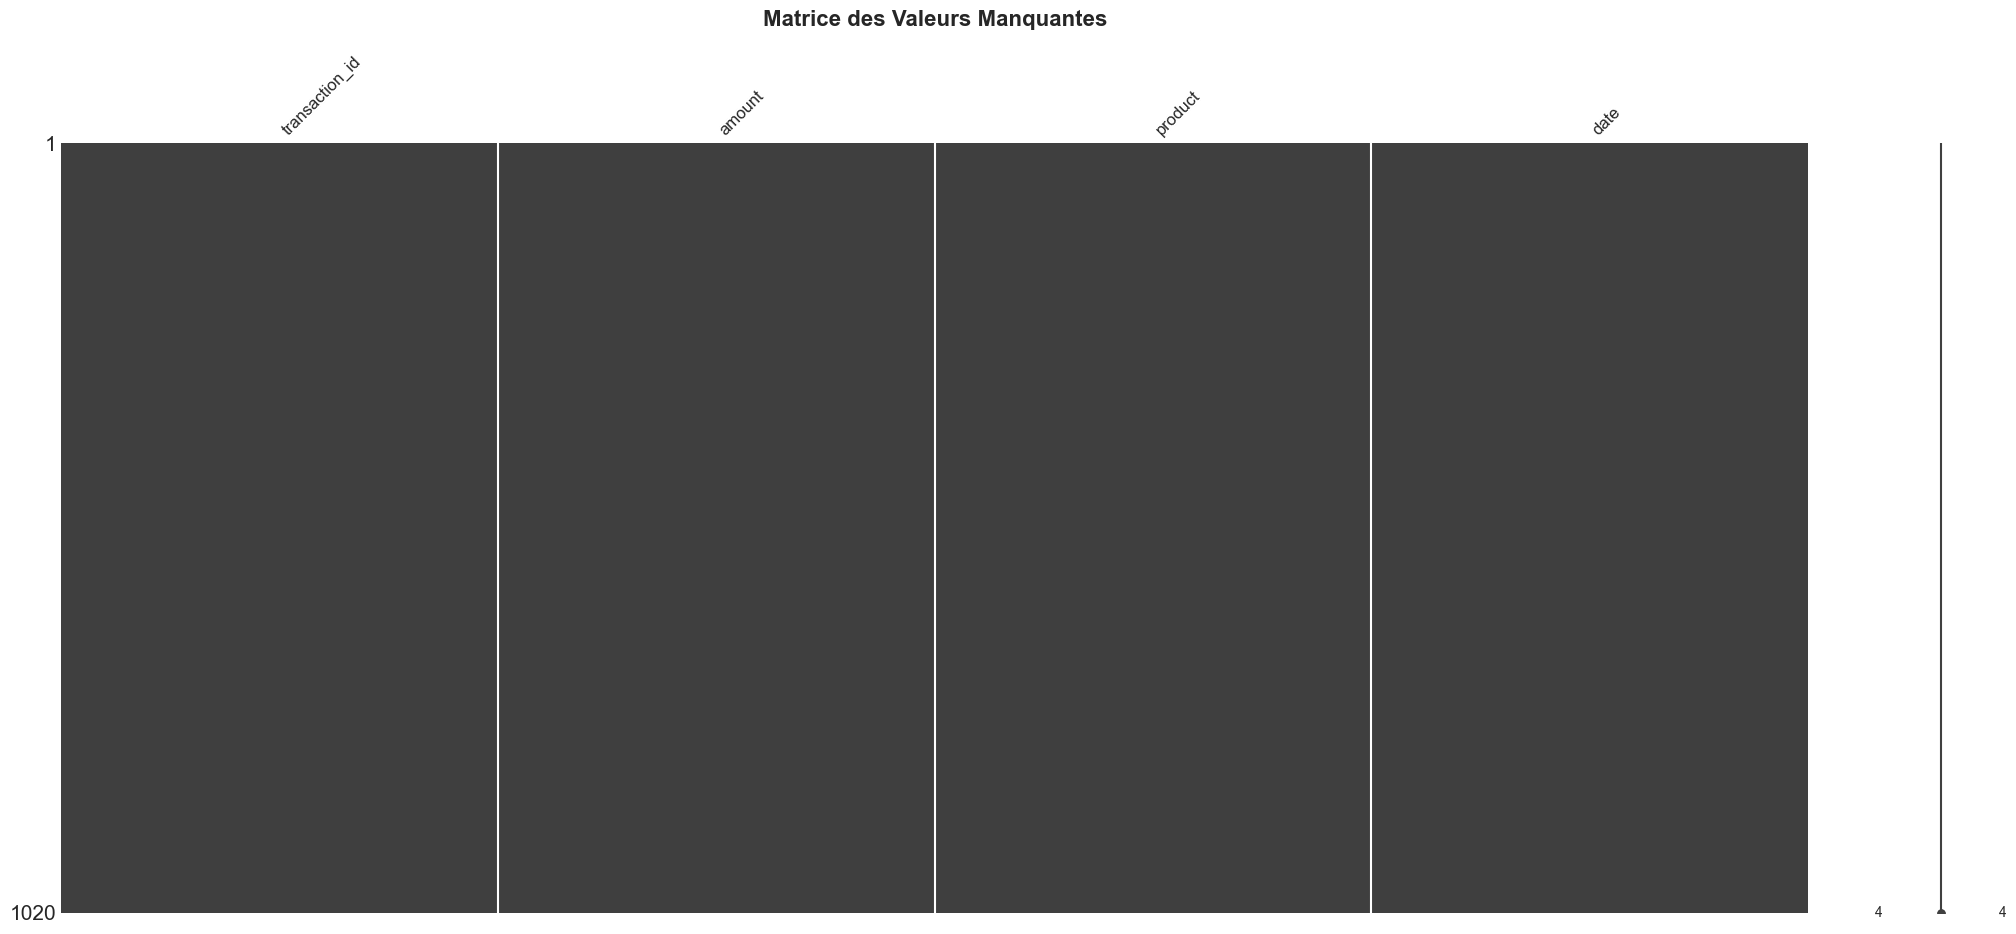


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [3]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Quelle est la distribution de la colonne 'amount' ?
2. Y a-t-il des valeurs négatives dans les montants ?
3. Quel est le montant maximum et semble-t-il aberrant ?
4. Combien d'outliers détecte la méthode IQR pour 'amount' ?
5. Combien d'outliers détecte la méthode Z-score (threshold=3) ?
6. Les deux méthodes identifient-elles les mêmes outliers ?
7. Quelle proportion du dataset représentent les outliers ?
8. Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
9. Les outliers sont-ils des erreurs ou des valeurs légitimes ?
10. Comment la moyenne change-t-elle après traitement des outliers ?


In [4]:

# 1. Quelle est la distribution de la colonne 'amount' ?

df['amount'].describe()

count     1020.00
mean      8616.96
std      20525.04
min         79.57
25%       1441.20
50%       3152.76
75%       7221.39
max     185913.06
Name: amount, dtype: float64

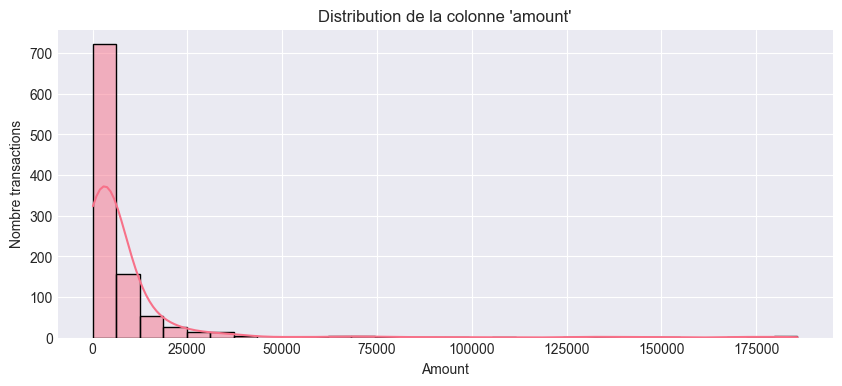

In [5]:
plt.figure(figsize=(10, 4))
sns.histplot(df['amount'], bins=30, kde=True)
plt.title("Distribution de la colonne 'amount'")
plt.xlabel("Amount")
plt.ylabel("Nombre transactions")
plt.show()

In [6]:
# 2. Y a-t-il des valeurs négatives dans les montants ?

df['amount'].min()

np.float64(79.57)

In [7]:
# 3. Quel est le montant maximum et semble-t-il aberrant ?

df['amount'].max()

# Oui

np.float64(185913.06)

In [8]:
# 4. Combien d'outliers détecte la méthode IQR pour 'amount' ?

# Détection par IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Utilisation
outliers, lower, upper = detect_outliers_iqr(df, 'amount')
print(f"Nombre d'outliers: {len(outliers)}")
print(f"Limites: [{lower:.2f}, {upper:.2f}]")

Nombre d'outliers: 105
Limites: [-7229.09, 15891.68]


In [9]:
# 5. Combien d'outliers détecte la méthode Z-score (threshold=3) ?

from scipy import stats
import numpy as np

# Calcul du Z-score
z_scores = np.abs(stats.zscore(df['amount']))
threshold = 3

# Détection des outliers
outliers_2 = df[z_scores > threshold]
print(f"Outliers détectés: {len(outliers_2)}")

Outliers détectés: 22


In [10]:
# 6. Les deux méthodes identifient-elles les mêmes outliers ?

# Non

In [11]:
# 7. Quelle proportion du dataset représentent les outliers ?

pour_out_IQR = 105 * 100 / 1020
pour_out_IQR

10.294117647058824

In [12]:
pour_out_Zscore = 22 * 100 / 1020
pour_out_Zscore

2.156862745098039

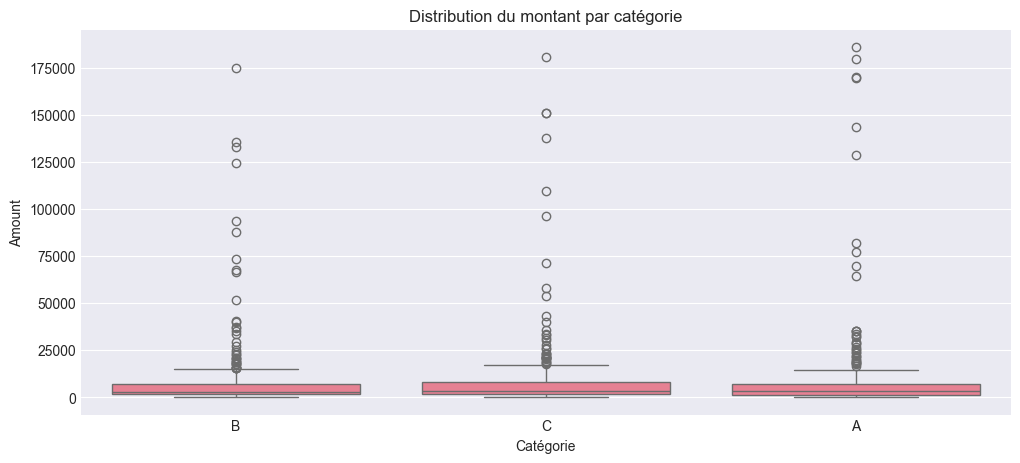

In [13]:
# 8. Y a-t-il une corrélation entre outliers et une catégorie spécifique ?

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='product', y='amount')
plt.title("Distribution du montant par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Amount")
plt.show()

In [14]:
# 9. Les outliers sont-ils des erreurs ou des valeurs légitimes ?

# valeurs légitimes

In [15]:
# 10. Comment la moyenne change-t-elle après traitement des outliers ?

df['amount'].mean()

np.float64(8616.955029411763)

In [16]:
# J'applique le Capping (Winsorization)

df_clean = df.copy()

lower = 0
upper = df_clean['amount'].quantile(0.90)

df_clean['amount'] = df_clean['amount'].clip(lower=lower, upper=upper)

In [17]:
df_clean['amount'].mean()

np.float64(5213.516170588236)

In [18]:
# La moyenne diminue significativement lorsque l'on enlève les 10 % d'outliers 

## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Visualiser la distribution avec boxplot et histogramme
### Étape 2: Calculer les statistiques descriptives
### Étape 3: Implémenter la détection par méthode IQR
### Étape 4: Implémenter la détection par Z-score
### Étape 5: Comparer les résultats des deux méthodes
### Étape 6: Décider d'une stratégie: suppression ou capping
### Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
### Étape 8: Visualiser la distribution avant/après traitement
### Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
### Étape 10: Documenter les outliers traités dans un rapport


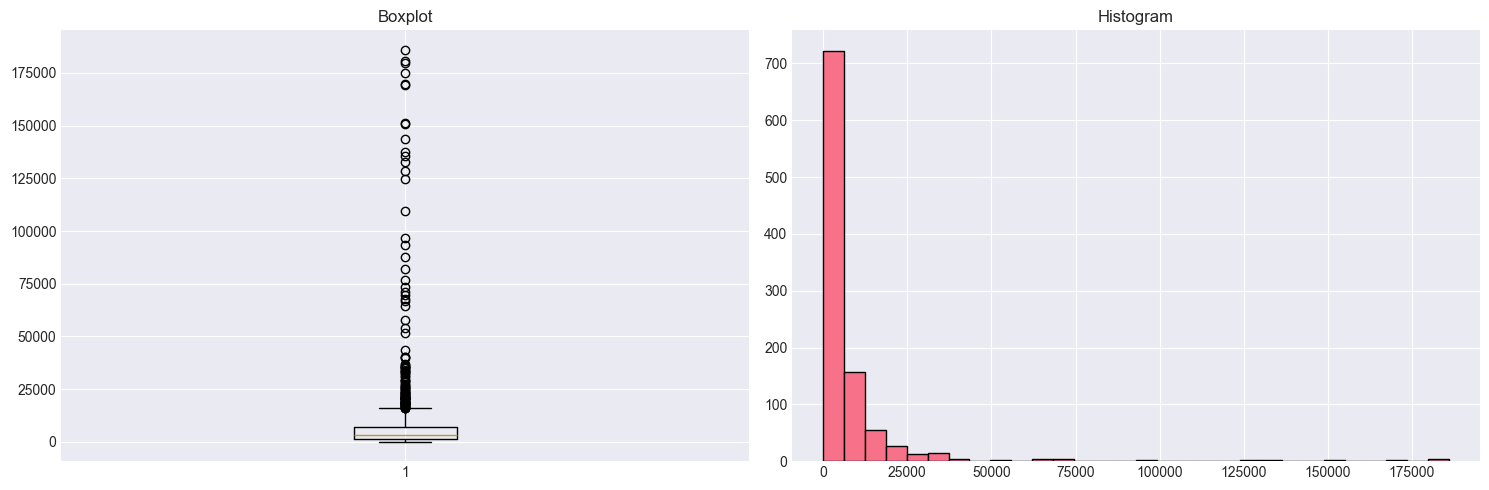

 Étape 1 complétée


In [19]:
# ========================================
# Étape 1: Visualiser la distribution avec boxplot et histogramme
# ========================================

# TODO: Écrivez votre code ici

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
axes[0].boxplot(df['amount'])
axes[0].set_title('Boxplot')

# Histogram
axes[1].hist(df['amount'], bins=30, edgecolor='black')
axes[1].set_title('Histogram')

plt.tight_layout()
plt.show()

# Vérification
print(f" Étape 1 complétée")

In [20]:
# ========================================
# Étape 2: Calculer les statistiques descriptives
# ========================================

# TODO: Écrivez votre code ici

df['amount'].describe()

count     1020.00
mean      8616.96
std      20525.04
min         79.57
25%       1441.20
50%       3152.76
75%       7221.39
max     185913.06
Name: amount, dtype: float64

In [21]:
# Vérification
print(f" Étape 2 complétée")

 Étape 2 complétée


In [22]:
# ========================================
# Étape 3: Implémenter la détection par méthode IQR
# ========================================

# TODO: Écrivez votre code ici

# Détection par IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Utilisation
outliers, lower, upper = detect_outliers_iqr(df, 'amount')
print(f"Nombre d'outliers: {len(outliers)}")
print(f"Limites: [{lower:.2f}, {upper:.2f}]")

# Vérification
print(f" Étape 3 complétée")

Nombre d'outliers: 105
Limites: [-7229.09, 15891.68]
 Étape 3 complétée


In [23]:
# ========================================
# Étape 4: Implémenter la détection par Z-score
# ========================================

# TODO: Écrivez votre code ici

# Voir question 5 en haut

# Vérification
print(f" Étape 4 complétée")

 Étape 4 complétée


In [24]:
# ========================================
# Étape 5: Comparer les résultats des deux méthodes
# ========================================

# TODO: Écrivez votre code ici

# 105 outliers avec IQR
# 22 outliers avec Z-score

# Vérification
print(f" Étape 5 complétée")

 Étape 5 complétée


In [25]:
# ========================================
# Étape 6: Décider d'une stratégie: suppression ou capping
# ========================================

# TODO: Écrivez votre code ici

# J'ai choisi capping car je pense que ce sont des outliers légitimes
# voir question 10 en haut

# Vérification
print(f" Étape 6 complétée")

 Étape 6 complétée


In [26]:
# ========================================
# Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
# ========================================

# TODO: Écrivez votre code ici

# voir question 10

# Vérification
print(f" Étape 7 complétée")

 Étape 7 complétée


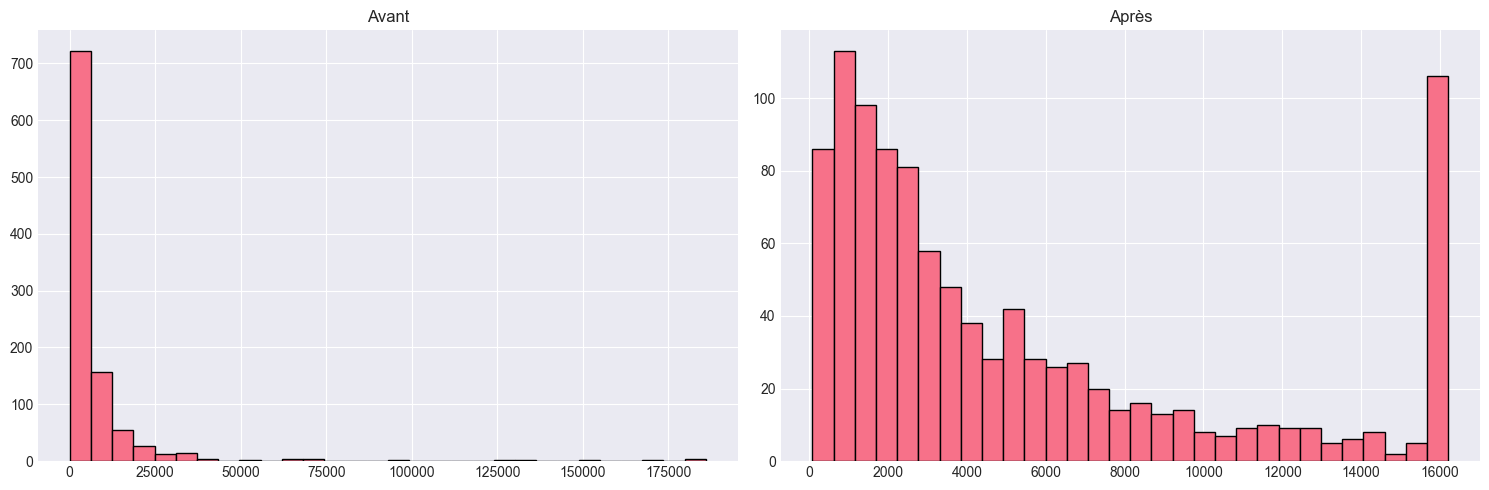

In [27]:
# ========================================
# Étape 8: Visualiser la distribution avant/après traitement
# ========================================

# TODO: Écrivez votre code ici

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Avant
axes[0].hist(df['amount'], bins=30, edgecolor='black')
axes[0].set_title('Avant')

# Après
axes[1].hist(df_clean['amount'], bins=30, edgecolor='black')
axes[1].set_title('Après')

plt.tight_layout()
plt.show()

In [28]:
# Vérification
print(f" Étape 8 complétée")

 Étape 8 complétée


In [29]:
# ========================================
# Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
# ========================================

# TODO: Écrivez votre code ici

print(f"La moyenne avant : {df['amount'].mean()}")
print(f"La moyenne après : {df_clean['amount'].mean()}")

print(f"L'écart type avant : {df['amount'].std()}")
print(f"L'écart type après : {df_clean['amount'].std()}")

# Vérification
print(f" Étape 9 complétée")

La moyenne avant : 8616.955029411763
La moyenne après : 5213.516170588236
L'écart type avant : 20525.041763921632
L'écart type après : 4990.995646369967
 Étape 9 complétée


In [30]:
# ========================================
# Étape 10: Documenter les outliers traités dans un rapport
# ========================================

# TODO: Écrivez votre code ici

# Documentation détaillée du traitement des outliers sur 'amount'
outliers_doc = {
    'amount': {
        'Detection_IQR': "105 outliers détectés",
        'Detection_ZScore': "22 outliers détectés",
        'Methode_Traitement': "Capping (Winsorization)",
        'Justification': "Outliers légitimes (pas d'erreurs de saisie, mais valeurs extrêmes réelles)",
        'Impact_Moyenne': "8 616.96  ➜  5 213.52 (-39.5%)",
        'Impact_Ecart_Type': "20 525.04  ➜  4 99&.00 (-75.7%)"
    }
}

rapport = {
    'Dimensions_initiales': (1020, 4),
    'Dimensions_finales': df.shape,
    'Total_outliers_traites': 105,
    'Detail_outliers': outliers_doc,
    'Transformations_appliquees': [
        "Détection des prix aberrants par IQR (105) et Z-score (22)",
        "Application d'un Capping (Winsorization) sur la colonne 'amount' (outliers conservés et plafonnés)",
        "Réduction de la variance et stabilisation de la moyenne de la colonne 'amount'"
    ]
}

# --- AFFICHAGE DU RAPPORT ---
print("=" * 80)
print(" " * 20 + "📊 DOCUMENTATION DES OUTLIERS - AMOUNT")
print("=" * 80)

print(f"\n• Variable analysée : AMOUNT")
print(f"   - Nombre total de lignes : 1 020")
print(f"   - Détection IQR          : {outliers_doc['amount']['Detection_IQR']}")
print(f"   - Détection Z-Score      : {outliers_doc['amount']['Detection_ZScore']}")
print(f"   - Traitement choisi      : {outliers_doc['amount']['Methode_Traitement']}")
print(f"   - Motif / Justification  : {outliers_doc['amount']['Justification']}")

print("\n   📈 IMPACT STATISTIQUE DU CAPPING :")
print(f"     • Moyenne    : {outliers_doc['amount']['Impact_Moyenne']}")
print(f"     • Écart-type : {outliers_doc['amount']['Impact_Ecart_Type']}")

print("\n" + "-" * 80)
print("📝 HISTORIQUE DES TRANSFORMATIONS")
print("-" * 80)
for transfo in rapport['Transformations_appliquees']:
    print(f"   • {transfo}")

print("=" * 80)

# Vérification
print(f" Étape 10 complétée")

                    📊 DOCUMENTATION DES OUTLIERS - AMOUNT

• Variable analysée : AMOUNT
   - Nombre total de lignes : 1 020
   - Détection IQR          : 105 outliers détectés
   - Détection Z-Score      : 22 outliers détectés
   - Traitement choisi      : Capping (Winsorization)
   - Motif / Justification  : Outliers légitimes (pas d'erreurs de saisie, mais valeurs extrêmes réelles)

   📈 IMPACT STATISTIQUE DU CAPPING :
     • Moyenne    : 8 616.96  ➜  5 213.52 (-39.5%)
     • Écart-type : 20 525.04  ➜  4 99&.00 (-75.7%)

--------------------------------------------------------------------------------
📝 HISTORIQUE DES TRANSFORMATIONS
--------------------------------------------------------------------------------
   • Détection des prix aberrants par IQR (105) et Z-score (22)
   • Application d'un Capping (Winsorization) sur la colonne 'amount' (outliers conservés et plafonnés)
   • Réduction de la variance et stabilisation de la moyenne de la colonne 'amount'
 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [31]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df_clean.shape, 
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,
    'Outliers_traités': 105,
    'Transformations_appliquées': ["Capping (Winsorization)"]
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n🎉 TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (1020, 4)
Dimensions_finales...................... (1020, 4)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 105
Transformations_appliquées.............. ['Capping (Winsorization)']

🎉 TP terminé avec succès!
